# Interactive Jaw Masking (For pure Side Profiles)
Since fully automated facial landmarkers (like MediaPipe) require at least a partial view of both eyes, they often fail on pure 90-degree side profiles. 

This alternative notebook uses an advanced Face Parsing model to extract your face's perfect silhouette and jawline, and then lets you **click exactly two points** to place the jaw mask perfectly!

In [1]:
import cv2
import numpy as np
import torch
from PIL import Image, ImageTk
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog

In [2]:
# Initialize Face Parser
print("Loading Face Parser model...")
processor = SegformerImageProcessor.from_pretrained("jonathandinu/face-parsing")
model = SegformerForSemanticSegmentation.from_pretrained("jonathandinu/face-parsing")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Model ready!")

Loading Face Parser model...


Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

Model ready!


In [3]:
print("Opening file dialog... Please check your taskbar for the popup window.")
root = tk.Tk()
root.attributes('-topmost', True)
root.withdraw()

file_path = filedialog.askopenfilename(
    title="Select a Side Profile Image",
    filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp")]
)
root.destroy()

if file_path:
    print(f"Selected file: {file_path}")
    print("Run the next cell to interactively place the mask!")
else:
    print("No file selected.")


Opening file dialog... Please check your taskbar for the popup window.
Selected file: C:/Users/PratikJPatel/Downloads/right-profile.png
Run the next cell to interactively place the mask!


Analyzing face silhouette...

A popup window has opened! (Check your taskbar)
Please click exactly TWO points on the image:
  Click 1: The Earlobe (Top-back corner of your jaw mask)
  Click 2: The Upper Lip corner (Top-front corner of your jaw mask)


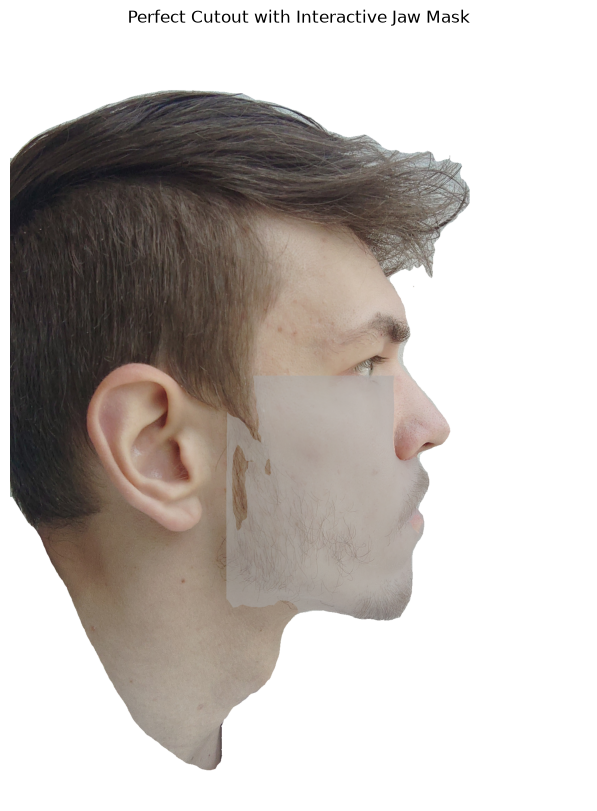

In [4]:
if 'file_path' in locals() and file_path:
    image = cv2.imread(file_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image_rgb.shape
    
    # --- 1. Face Parsing for Silhouette & Jawline ---
    print("Analyzing face silhouette...")
    pil_image = Image.fromarray(image_rgb)
    inputs = processor(images=pil_image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits
    upsampled = torch.nn.functional.interpolate(
        logits, size=pil_image.size[::-1], mode="bilinear", align_corners=False
    )
    labels = upsampled.argmax(dim=1)[0].cpu().numpy()
    
    # Classes 1-17 are person features. Class 1 is face skin (which stops perfectly at the jawline!).
    person_mask = np.isin(labels, list(range(1, 18)))
    skin_mask = (labels == 1).astype(np.uint8)
    
    bg_image = np.ones_like(image_rgb) * 255
    cutout_image = np.where(person_mask[..., None], image_rgb, bg_image)
    
    # --- 2. Interactive Clicking ---
    clicks = []
    
    # Scale image for display if too large
    max_dim = 800
    scale = 1.0
    if h > max_dim or w > max_dim:
        scale = max_dim / max(h, w)
        new_w, new_h = int(w * scale), int(h * scale)
        display_img = cv2.resize(image_rgb, (new_w, new_h))
    else:
        display_img = image_rgb.copy()
        
    click_root = tk.Tk()
    click_root.title("CLICK 2 POINTS: 1. Earlobe, 2. Upper Lip Corner")
    click_root.attributes('-topmost', True)
    
    tk_pil = Image.fromarray(display_img)
    tk_img = ImageTk.PhotoImage(tk_pil)
    canvas = tk.Canvas(click_root, width=tk_img.width(), height=tk_img.height(), cursor="crosshair")
    canvas.pack()
    canvas.create_image(0, 0, anchor=tk.NW, image=tk_img)
    
    print("\nA popup window has opened! (Check your taskbar)")
    print("Please click exactly TWO points on the image:")
    print("  Click 1: The Earlobe (Top-back corner of your jaw mask)")
    print("  Click 2: The Upper Lip corner (Top-front corner of your jaw mask)")
    
    def on_click(event):
        orig_x, orig_y = int(event.x / scale), int(event.y / scale)
        clicks.append((orig_x, orig_y))
        r = 3
        canvas.create_oval(event.x-r, event.y-r, event.x+r, event.y+r, fill='red', outline='red')
        
        if len(clicks) == 2:
            click_root.quit()
            click_root.destroy()
            
    canvas.bind("<Button-1>", on_click)
    click_root.mainloop()
    
    if len(clicks) == 2:
        ear_x, ear_y = clicks[0]
        lip_x, lip_y = clicks[1]
        
        # Create bounding polygon
        # Line 1: Earlobe to Lip (Top edge)
        # Line 2: Straight down from Lip (Front edge)
        # The rest goes to the bottom corners of the image.
        
        poly_mask = np.zeros((h, w), dtype=np.uint8)
        facing_right = lip_x > ear_x # Nose is to the right
        
        if facing_right:
            pts = np.array([
                [ear_x, ear_y],
                [lip_x, lip_y],
                [lip_x, h],
                [0, h],
                [0, ear_y]
            ])
        else:
            pts = np.array([
                [lip_x, lip_y],
                [ear_x, ear_y],
                [w, ear_y],
                [w, h],
                [lip_x, h]
            ])
            
        cv2.fillPoly(poly_mask, [pts], 1)
        
        # Final mask: The intersection of the user's polygon and the parser's skin mask
        # (This automatically perfectly traces the actual anatomical jawline!)
        final_jaw_mask = cv2.bitwise_and(skin_mask, poly_mask)
        
        overlay = cutout_image.copy()
        overlay[final_jaw_mask == 1] = [170, 170, 170]
        
        alpha = 0.55
        final_image = cv2.addWeighted(overlay, alpha, cutout_image, 1 - alpha, 0)
        
        plt.figure(figsize=(10, 10))
        plt.imshow(final_image)
        plt.axis('off')
        plt.title("Perfect Cutout with Interactive Jaw Mask")
        plt.show()
    else:
        print("You didn't click two points!")
else:
    print("Please run the upload cell first!")
